# 06 — Gravitational differential

Synthesize a differential-acceleration noise floor, inject an equivalence-principle-violation line at the MICROSCOPE modulation frequency, and score it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from anomalymetric.gravitational.score import grav_score
from anomalymetric.gravitational.fifth_force import microscope_modulation_freq_hz, ep_eta_to_amplitude
from anomalymetric.ingest.synthetic_psd import synthetic_grav_natural, synthetic_grav_with_exotic
from anomalymetric.units import bin_centers_eV, ev_to_hz, H_PLANCK_EV_S

In [2]:
# Differential-acceleration noise floor and an injected equivalence-principle line.
bg = synthetic_grav_natural(seed=0)
base = synthetic_grav_natural(seed=1, noise=False)
f_ep = microscope_modulation_freq_hz()
sig = synthetic_grav_with_exotic(base, line_E_eV=H_PLANCK_EV_S*f_ep, line_amplitude=8.0, seed=2)
print('MICROSCOPE f_EP = %.3e Hz' % f_ep)

MICROSCOPE f_EP = 1.682e-04 Hz


In [3]:
r_bg, r_sig = grav_score(bg), grav_score(sig)
print('noise : TS=%.2f score=%.2f best=%s' % (r_bg.test_statistic, r_bg.anomaly_score, r_bg.best_template))
print('EP    : TS=%.2f score=%.2f best=%s' % (r_sig.test_statistic, r_sig.anomaly_score, r_sig.best_template))

noise : TS=4.87 score=0.93 best=oscdm.1e-17eV
EP    : TS=25160.78 score=300.00 best=ep.microscope


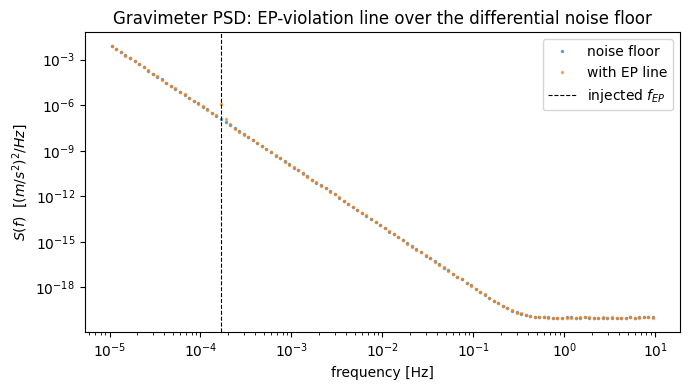

In [4]:
f = ev_to_hz(bin_centers_eV(sig.log_energy_edges_eV))
plt.figure(figsize=(7,4))
plt.loglog(f, bg.value, '.', ms=3, label='noise floor', alpha=0.6)
plt.loglog(f, sig.value, '.', ms=3, label='with EP line', alpha=0.6)
plt.axvline(f_ep, color='k', ls='--', lw=0.8, label='injected $f_{EP}$')
plt.xlabel('frequency [Hz]'); plt.ylabel(r'$S(f)$  [$(m/s^2)^2/Hz$]')
plt.legend(); plt.title('Gravimeter PSD: EP-violation line over the differential noise floor')
plt.tight_layout()